Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
✓ Visualization libraries loaded
 Data reloaded with validation

JUDICIAL BACKLOG STATISTICS (VALIDATED DATA)
Average Duration:    277 days
Median Duration:     69 days
Max Duration:        5482 days
Long-running Cases:  6.1%
Pending Cases:       0.0%



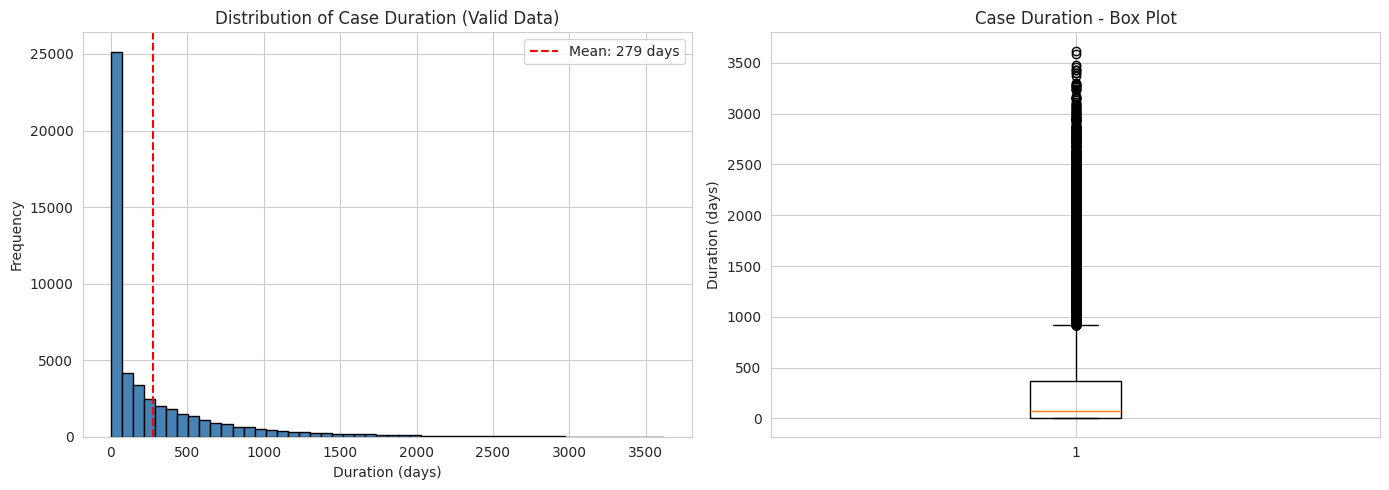

✓ Duration distribution visualized (50,000 samples)


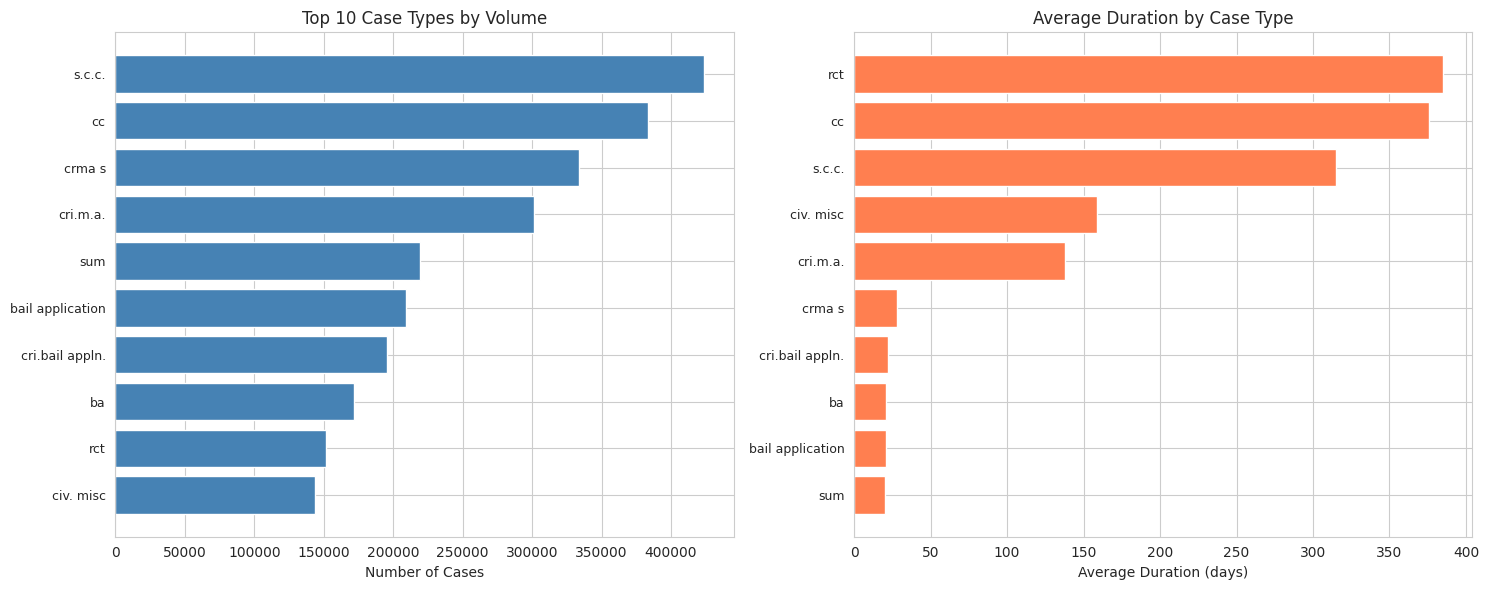

 Case type analysis complete (11,254 unique types)


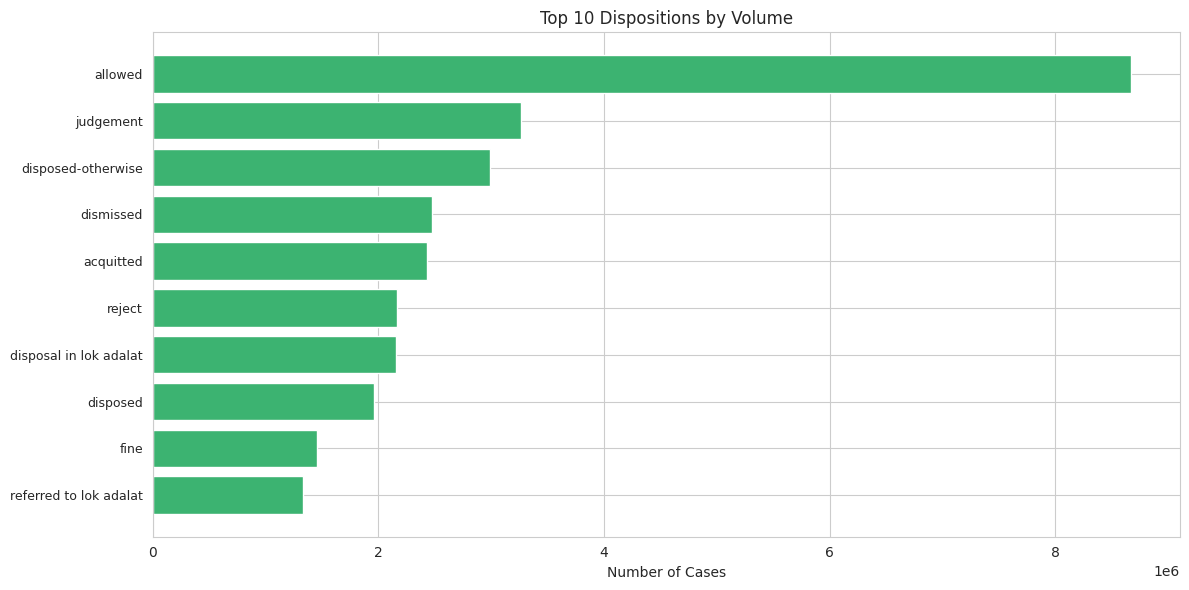

✓ Disposition analysis complete (52 unique dispositions)
Valid tenure records: 26
Tenure range: 0 - 25 years


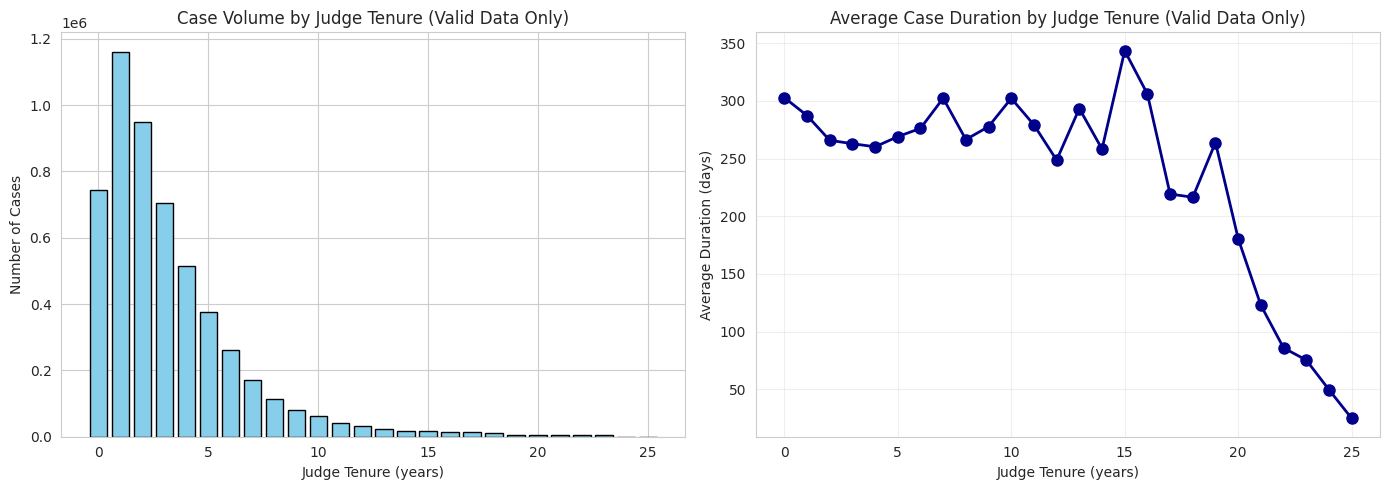

 Judge tenure analysis complete (NO NEGATIVE VALUES)


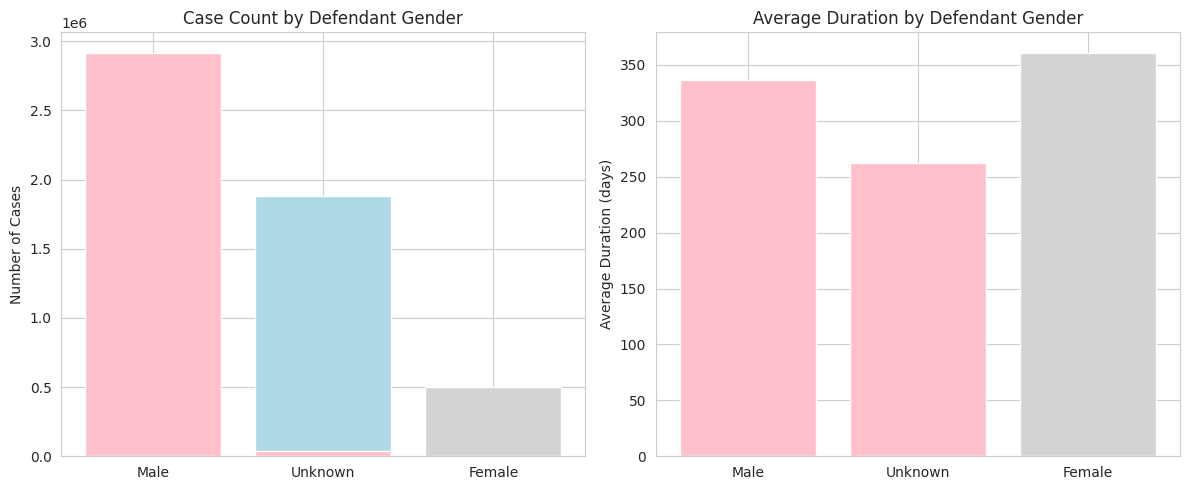

✓ Gender analysis complete


In [0]:
# COMMAND ----------

# MAGIC %md
# MAGIC # 2. Exploratory Data Analysis
# MAGIC Valid data only - no negative values

# COMMAND ----------

%pip install polars pandas matplotlib seaborn

# COMMAND ----------

import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print(" Visualization libraries loaded")

# COMMAND ----------

# MAGIC %md
# MAGIC ## Quick Data Reload

# COMMAND ----------

judges = pl.read_csv("/Workspace/Users/sumedha190198@gmail.com/judicial-backlog/judges_clean.csv")
disp_key = pl.read_csv("/Workspace/Users/sumedha190198@gmail.com/judicial-backlog/disp_name_key.csv")
type_key = pl.read_csv("/Workspace/Users/sumedha190198@gmail.com/judicial-backlog/type_name_key.csv")
purpose_key = pl.read_csv("/Workspace/Users/sumedha190198@gmail.com/judicial-backlog/purpose_name_key.csv")

lf_sample = pl.scan_parquet("/Workspace/Users/sumedha190198@gmail.com/judicial-backlog/cases_sample_10pct.parquet")

judges = judges.with_columns([
    pl.col("start_date").str.to_date("%d-%m-%Y", strict=False).alias("judge_start"),
    pl.col("end_date").str.to_date("%d-%m-%Y", strict=False).alias("judge_end"),
])

judges_valid = judges.filter(pl.col("judge_start").is_not_null())
judges_lazy = judges_valid.lazy()

lf_filtered = (
    lf_sample
    .filter((pl.col("duration_days") >= 0) & (pl.col("duration_days") <= 7300))
    .join(judges_lazy.select(["state_code", "dist_code", "court_no", "judge_position", "judge_start"]),
          on=["state_code", "dist_code", "court_no", "judge_position"], how="left")
    .with_columns([(pl.col("filing_date").dt.year() - pl.col("judge_start").dt.year()).alias("judge_tenure_years")])
    .filter(pl.col("judge_start").is_not_null())
    .filter(pl.col("filing_date") >= pl.col("judge_start"))
    .filter(pl.col("judge_tenure_years") >= 0)
    .filter(pl.col("judge_tenure_years") <= 50)
)

print(" Data reloaded with validation")

# COMMAND ----------

# MAGIC %md
# MAGIC ## Basic Statistics

# COMMAND ----------

stats = lf_filtered.select([
    pl.col("duration_days").mean().alias("avg_duration"),
    pl.col("duration_days").median().alias("median_duration"),
    pl.col("duration_days").max().alias("max_duration"),
    pl.col("long_running").mean().alias("long_running_pct"),
    pl.col("censored").mean().alias("censored_pct"),
]).collect()

stats_dict = stats.to_dicts()[0]

print(f"""
JUDICIAL BACKLOG STATISTICS (VALIDATED DATA)
=============================================
Average Duration:    {stats_dict['avg_duration']:.0f} days
Median Duration:     {stats_dict['median_duration']:.0f} days
Max Duration:        {stats_dict['max_duration']:.0f} days
Long-running Cases:  {stats_dict['long_running_pct']:.1%}
Pending Cases:       {stats_dict['censored_pct']:.1%}
""")

# COMMAND ----------

# MAGIC %md
# MAGIC ## Duration Distribution

# COMMAND ----------

df_viz = (
    lf_filtered
    .select(["duration_days"])
    .collect()
    .to_pandas()
    .sample(n=min(50000, 100000), random_state=42)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_viz['duration_days'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Duration (days)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Case Duration (Valid Data)')
axes[0].axvline(df_viz['duration_days'].mean(), color='red', linestyle='--', 
                label=f"Mean: {df_viz['duration_days'].mean():.0f} days")
axes[0].legend()

axes[1].boxplot(df_viz['duration_days'])
axes[1].set_ylabel('Duration (days)')
axes[1].set_title('Case Duration - Box Plot')

plt.tight_layout()
plt.show()

print(f" Duration distribution visualized ({len(df_viz):,} samples)")

# COMMAND ----------

# MAGIC %md
# MAGIC ## Case Type Breakdown

# COMMAND ----------

type_stats = (
    lf_filtered
    .with_columns([pl.col("type_name").cast(pl.Int64)])
    .join(type_key.lazy(), on="type_name", how="left")
    .group_by("type_name_s")
    .agg([
        pl.len().alias("count"),
        pl.col("duration_days").mean().alias("avg_duration"),
        pl.col("long_running").mean().alias("long_running_pct"),
    ])
    .sort("count", descending=True)
    .collect()
    .to_pandas()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

top_types = type_stats.head(10).sort_values('count', ascending=True)
axes[0].barh(range(len(top_types)), top_types['count'], color='steelblue')
axes[0].set_yticks(range(len(top_types)))
axes[0].set_yticklabels(top_types['type_name_s'], fontsize=9)
axes[0].set_xlabel('Number of Cases')
axes[0].set_title('Top 10 Case Types by Volume')

top_types_dur = type_stats.head(10).sort_values('avg_duration', ascending=True)
axes[1].barh(range(len(top_types_dur)), top_types_dur['avg_duration'], color='coral')
axes[1].set_yticks(range(len(top_types_dur)))
axes[1].set_yticklabels(top_types_dur['type_name_s'], fontsize=9)
axes[1].set_xlabel('Average Duration (days)')
axes[1].set_title('Average Duration by Case Type')

plt.tight_layout()
plt.show()

print(f" Case type analysis complete ({len(type_stats):,} unique types)")

# COMMAND ----------

# MAGIC %md
# MAGIC ## Disposition Breakdown

# COMMAND ----------

disp_stats = (
    lf_filtered
    .with_columns([pl.col("disp_name").cast(pl.Int64)])
    .join(disp_key.lazy(), on="disp_name", how="left")
    .group_by("disp_name_s")
    .agg([
        pl.len().alias("count"),
        pl.col("duration_days").mean().alias("avg_duration"),
    ])
    .sort("count", descending=True)
    .collect()
    .to_pandas()
)

fig, ax = plt.subplots(figsize=(12, 6))
top_disp = disp_stats.head(10).sort_values('count', ascending=True)
ax.barh(range(len(top_disp)), top_disp['count'], color='mediumseagreen')
ax.set_yticks(range(len(top_disp)))
ax.set_yticklabels(top_disp['disp_name_s'], fontsize=9)
ax.set_xlabel('Number of Cases')
ax.set_title('Top 10 Dispositions by Volume')
plt.tight_layout()
plt.show()

print(f" Disposition analysis complete ({len(disp_stats):,} unique dispositions)")

# COMMAND ----------

# MAGIC %md
# MAGIC ## Judge Tenure Impact 

# COMMAND ----------

tenure_breakdown = (
    lf_filtered
    .group_by("judge_tenure_years")
    .agg([
        pl.len().alias("count"),
        pl.col("duration_days").mean().alias("avg_duration"),
    ])
    .sort("judge_tenure_years")
    .collect()
    .to_pandas()
)

print(f"Valid tenure records: {len(tenure_breakdown):,}")
print(f"Tenure range: {tenure_breakdown['judge_tenure_years'].min():.0f} - {tenure_breakdown['judge_tenure_years'].max():.0f} years")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(tenure_breakdown['judge_tenure_years'], tenure_breakdown['count'], color='skyblue', edgecolor='black')
axes[0].set_xlabel('Judge Tenure (years)')
axes[0].set_ylabel('Number of Cases')
axes[0].set_title('Case Volume by Judge Tenure (Valid Data Only)')

axes[1].plot(tenure_breakdown['judge_tenure_years'], tenure_breakdown['avg_duration'], 
             marker='o', color='darkblue', linewidth=2, markersize=8)
axes[1].set_xlabel('Judge Tenure (years)')
axes[1].set_ylabel('Average Duration (days)')
axes[1].set_title('Average Case Duration by Judge Tenure (Valid Data Only)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f" Judge tenure analysis complete (NO NEGATIVE VALUES)")

# COMMAND ----------

# MAGIC %md
# MAGIC ## Gender Analysis

# COMMAND ----------

gender_breakdown = (
    lf_filtered
    .group_by("female_defendant")
    .agg([
        pl.len().alias("count"),
        pl.col("duration_days").mean().alias("avg_duration"),
    ])
    .sort("count", descending=True)
    .collect()
    .to_pandas()
)

# Parse gender labels properly
def parse_gender(x):
    if isinstance(x, str):
        if 'female' in x.lower():
            return 'Female'
        elif 'male' in x.lower():
            return 'Male'
    return 'Unknown'

gender_breakdown['gender'] = gender_breakdown['female_defendant'].apply(parse_gender)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(gender_breakdown['gender'], gender_breakdown['count'], color=['pink', 'lightblue', 'lightgray'])
axes[0].set_ylabel('Number of Cases')
axes[0].set_title('Case Count by Defendant Gender')

axes[1].bar(gender_breakdown['gender'], gender_breakdown['avg_duration'], color=['pink', 'lightblue', 'lightgray'])
axes[1].set_ylabel('Average Duration (days)')
axes[1].set_title('Average Duration by Defendant Gender')

plt.tight_layout()
plt.show()

print(f" Gender analysis complete")

